# Data Preparation

# Imports


In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import joblib


## Importar dataset

In [48]:
# Carregar o arquivo CSV com o separador correto
dados = pd.read_csv('./data/consumo-total-nacional.csv', sep=';')

In [49]:
# Mostrar as 5 primeiras linhas
dados.head()

,Data/Hora,Dia,Mês,Ano,Data,Hora,Baixa Tensão (kWh),Média Tensão (kWh),Alta Tensão (kWh),Muito Alta Tensão (kWh),Total (kWh)
0,2023-01-01T04:15:00+00:00,1,1,2023,2023-01-01,04:15,5.864102e+05,215291.3637,135959.9653,28463.9642,9.661255e+05
1,2023-01-01T19:45:00+00:00,1,1,2023,2023-01-01,19:45,1.020963e+06,243999.0318,142650.6654,31552.6965,1.439165e+06
2,2023-01-02T02:15:00+00:00,2,1,2023,2023-01-02,02:15,5.761662e+05,229108.9093,141256.1339,28953.2937,9.754845e+05
3,2023-01-02T22:15:00+00:00,2,1,2023,2023-01-02,22:15,1.060578e+06,388166.5915,173746.8685,33583.4263,1.656075e+06
4,2023-01-03T14:00:00+00:00,3,1,2023,2023-01-03,14:00,8.787130e+05,564141.8898,187362.4179,82734.6573,1.712952e+06


## Verificação de Distribuição dos Dados

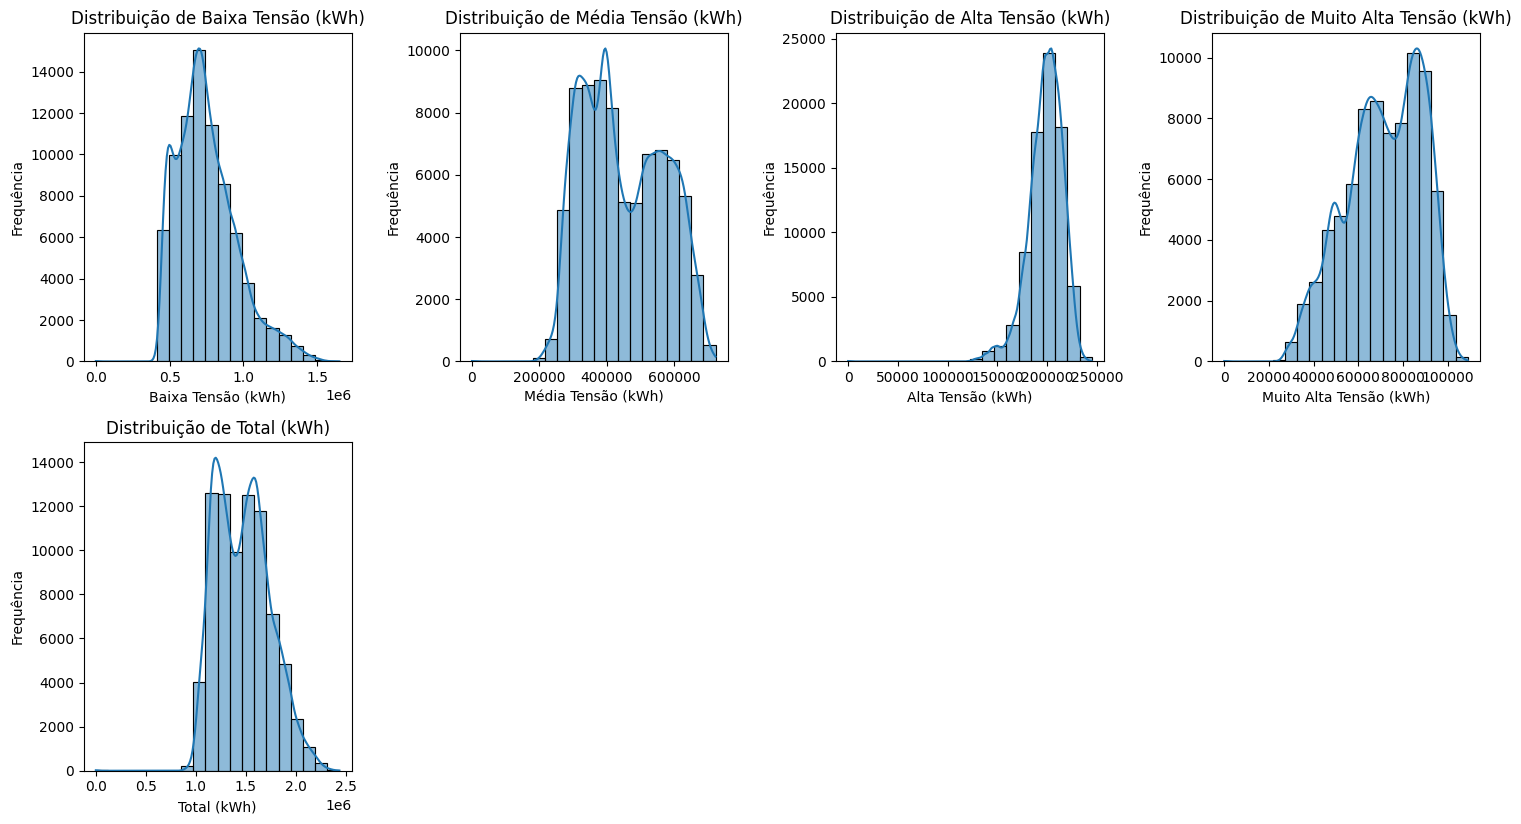

                Dia           Mês           Ano  Baixa Tensão (kWh)  \
count  79401.000000  79401.000000  79401.000000        7.940100e+04   
mean      15.628707      6.010050   2023.674727        7.544932e+05   
std        8.824941      3.549996      0.672041        2.049254e+05   
min        1.000000      1.000000   2023.000000        0.000000e+00   
25%        8.000000      3.000000   2023.000000        6.049383e+05   
50%       16.000000      6.000000   2024.000000        7.231350e+05   
75%       23.000000      9.000000   2024.000000        8.698441e+05   
max       31.000000     12.000000   2025.000000        1.651713e+06   

       Média Tensão (kWh)  Alta Tensão (kWh)  Muito Alta Tensão (kWh)  \
count        79401.000000       79401.000000             79401.000000   
mean        449750.794178      198602.932012             71447.333907   
std         119655.669938       17290.784606             16886.301737   
min              0.000000           0.000000                 0.00000

In [50]:
plt.figure(figsize=(15, 12))

# Criando histogramas para as variáveis de consumo de energia
for i, column in enumerate(dados.columns[6:], 1):  # Ignora a primeira coluna "Data/Hora"
    plt.subplot(3, 4, i)  # Alterado para 3 linhas e 4 colunas
    sns.histplot(dados[column], kde=True, bins=20)
    plt.title(f'Distribuição de {column}')
    plt.xlabel(column)
    plt.ylabel('Frequência')

plt.tight_layout()  # Ajusta o layout para que os gráficos não se sobreponham
plt.show()

# Cálculo de estatísticas descritivas (média, desvio padrão, etc.)
desc_stats = dados.describe()
print(desc_stats)



## Análise de Outliers

Isto está bem ???

In [51]:
# Análise de outliers usando o método IQR
outliers = {}

# Garantir que as colunas de interesse sejam do tipo numérico (remover ou corrigir valores não numéricos)
dados = dados.apply(pd.to_numeric, errors='coerce')

for column in dados.columns[5:]:  # Excluindo as colunas "Data/Hora", "Dia", "Mês", "Ano", "Data"
    # Verificar se a coluna é numérica antes de calcular os percentis
    if dados[column].dtype in ['float64', 'int64']:  # Garantir que estamos lidando com dados numéricos
        Q1 = dados[column].quantile(0.25)  # Primeiro quartil
        Q3 = dados[column].quantile(0.75)  # Terceiro quartil
        IQR = Q3 - Q1  # Intervalo Interquartil
        
        # Definindo os limites para detectar outliers
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Identificando os outliers
        outliers[column] = dados[(dados[column] < lower_bound) | (dados[column] > upper_bound)]
        
        # Exibindo os limites
        print(f"Outliers para {column}:")
        print(f"Limite inferior: {lower_bound}")
        print(f"Limite superior: {upper_bound}")
        print(f"Número de outliers: {outliers[column].shape[0]}")
        print("-" * 40)

# Opcional: Mostrar exemplos de outliers encontrados
for column, outlier_data in outliers.items():
    if outlier_data.shape[0] > 0:
        print(f"Exemplos de outliers para {column}:")
        print(outlier_data.head())  # Mostra os primeiros exemplos de outliers
        print("-" * 40)


Outliers para Hora:
Limite inferior: nan
Limite superior: nan
Número de outliers: 0
----------------------------------------
Outliers para Baixa Tensão (kWh):
Limite inferior: 207579.73520100006
Limite superior: 1267202.6781209998
Número de outliers: 1972
----------------------------------------
Outliers para Média Tensão (kWh):
Limite inferior: 36370.73125000001
Limite superior: 864027.57965
Número de outliers: 12
----------------------------------------
Outliers para Alta Tensão (kWh):
Limite inferior: 156130.419
Limite superior: 243370.58299999998
Número de outliers: 1852
----------------------------------------
Outliers para Muito Alta Tensão (kWh):
Limite inferior: 20825.1466
Limite superior: 124436.3714
Número de outliers: 12
----------------------------------------
Outliers para Total (kWh):
Limite inferior: 625596.4869180004
Limite superior: 2278696.54079
Número de outliers: 107
----------------------------------------
Exemplos de outliers para Baixa Tensão (kWh):
     Data/Hor

## Correlações

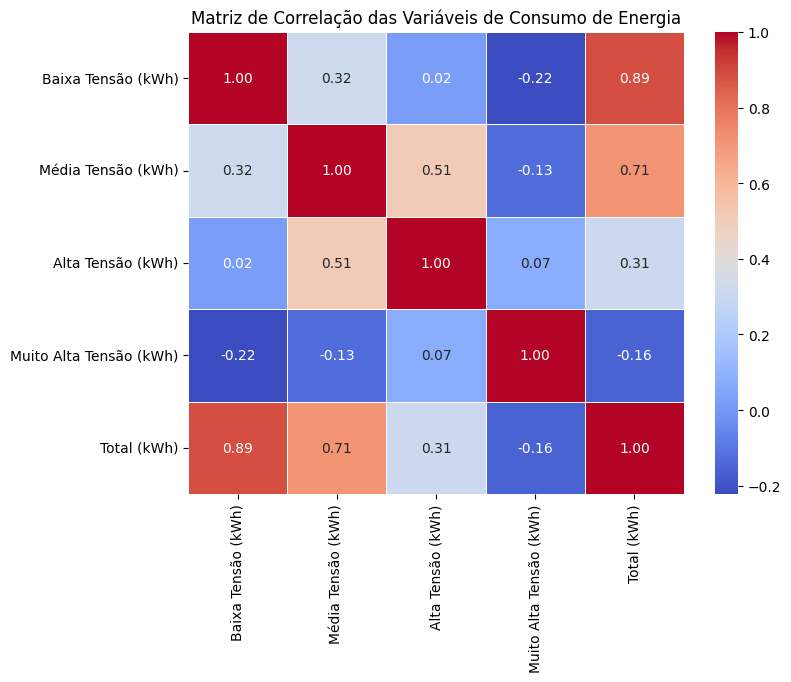

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

# Selecionar apenas as colunas numéricas (ignorando "Data/Hora", "Dia", "Mês", "Ano", "Data", "Hora")
dados_numericos = dados.drop(columns=['Data/Hora', 'Dia', 'Mês', 'Ano', 'Data', 'Hora'])

# Calcular a matriz de correlação
correlation_matrix = dados_numericos.corr()

# Visualizar a matriz de correlação com um gráfico de calor (heatmap)
plt.figure(figsize=(8, 6))  # Tamanho da figura
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlação das Variáveis de Consumo de Energia')
plt.show()


Principais observações:

* Baixa Tensão tem correlação muito forte com o Total (0.89), indicando que o **consumo em Baixa Tensão representa grande parte do consumo total de energia**.
* Média Tensão também tem correlação forte com o Total (0.71), sendo o **segundo maior contribuinte para o consumo total**.
* Alta Tensão tem correlação positiva moderada com o Total (0.31) e com a Média Tensão (0.51).
* Muito Alta Tensão apresenta correlações negativas com Baixa Tensão (-0.22), Média Tensão (-0.13) e com o Total (-0.16), sugerindo que quando o consumo em Muito Alta Tensão aumenta, tende a haver uma redução nos outros tipos de consumo, especialmente em Baixa Tensão.
* A Baixa Tensão e a Média Tensão apresentam correlação positiva fraca entre si (0.32).
* A correlação entre Baixa Tensão e Alta Tensão é praticamente inexistente (0.02).

Estas correlações sugerem que o consumo energético é dominado pelos consumidores de Baixa e Média Tensão, enquanto o consumo em Muito Alta Tensão parece seguir um padrão diferente e inversamente relacionado com os demais.

## Valores Ausentes

In [53]:
dados.isnull().sum()


Data/Hora                  79401
Dia                            0
Mês                            0
Ano                            0
Data                       79401
Hora                       79401
Baixa Tensão (kWh)             0
Média Tensão (kWh)             0
Alta Tensão (kWh)              0
Muito Alta Tensão (kWh)        0
Total (kWh)                    0
dtype: int64

## Normalização

In [54]:
colunas_para_normalizar = [
    'Baixa Tensão (kWh)',
    'Média Tensão (kWh)',
    'Alta Tensão (kWh)',
    'Muito Alta Tensão (kWh)',
    'Total (kWh)'
]


# Criar o scaler
scaler = MinMaxScaler()

# Ajustar e transformar
dados[colunas_para_normalizar] = scaler.fit_transform(dados[colunas_para_normalizar])

joblib.dump(scaler, 'scaler.pkl')
dados[colunas_para_normalizar].describe()



,Baixa Tensão (kWh),Média Tensão (kWh),Alta Tensão (kWh),Muito Alta Tensão (kWh),Total (kWh)
count,79401.000000,79401.000000,79401.000000,79401.000000,79401.000000
mean,0.456794,0.621503,0.810948,0.655774,0.604649
std,0.124068,0.165350,0.070603,0.154990,0.110647
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.366249,0.479157,0.771106,0.547762,0.510818
50%,0.437809,0.592929,0.817817,0.666880,0.601756
75%,0.526632,0.765089,0.860162,0.785509,0.680314
max,1.000000,1.000000,1.000000,1.000000,1.000000
